# E-commerce Data Analysis

---

## Цель проекта

Проанализировать транзакционные данные e-commerce бизнеса, чтобы выявить ключевые тенденции продаж, особенности поведения клиентов, эффективность товарного ассортимента и потенциальные риски для выручки.

---

## Основные бизнес-вопросы

1. Как распределяется выручка между странами и какие рынки формируют основной объём продаж?

2. Как изменяются продажи и другие ключевые показатели во времени?

3. Какова доля возвратов и как она распределяется между клиентами?

4. В какие периоды времени наблюдается наибольшая покупательская активность?

5. Какие товары являются наиболее востребованными и какие товары формируют наибольшую выручку?

6. Какие клиенты формируют наибольший вклад в выручку?

7. Какова доля повторных клиентов и насколько они отличаются от клиентов, совершивших только одну покупку?

8. Как распределена выручка между клиентами и насколько она концентрирована среди наиболее ценных клиентов?

9. Какие клиентские сегменты можно выделить с помощью RFM-анализа?

10. Как изменяется удержание клиентов в зависимости от месяца их первой покупки?

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

In [ ]:
from pathlib import Path

data_path = Path("../data/Online Retail.xlsx")
data = pd.read_excel(data_path)

## 1. Описание датасета и загрузка данных

Проект основан на транзакционных данных интернет-магазина **UCI Online Retail** за период с **01.12.2010 по 09.12.2011**.

Датасет содержит информацию о заказах, товарах, количестве проданных единиц, ценах, клиентах, странах и времени совершения покупок.

| Параметр      | Описание                  |
| ------------- | ------------------------- |
| `InvoiceNo`   | номер заказа              |
| `StockCode`   | артикул товара            |
| `Description` | описание товара           |
| `Quantity`    | количество единиц товара  |
| `InvoiceDate` | дата и время заказа       |
| `UnitPrice`   | цена одной единицы товара |
| `CustomerID`  | идентификатор клиента     |
| `Country`     | страна клиента            |

In [49]:
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [50]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 2. Оценка качества данных

---

Перед началом анализа проверяю структуру и качество исходных данных: полноту признаков, наличие дубликатов, корректность диапазонов значений и соответствие данных бизнес-логике.

In [54]:
print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} столбцов")
print(f"Период данных: {data['InvoiceDate'].min():%d.%m.%Y} — {data['InvoiceDate'].max():%d.%m.%Y}")
print("\nПропущенные значения:")
missing = data.isna().sum()
missing_pct = (missing / len(data) * 100).round(2)
missing_report = pd.DataFrame({"Пропущено": missing,"Доля, %": missing_pct})
print(missing_report[missing_report["Пропущено"] > 0])
print(f"\nУникальных заказов: {data['InvoiceNo'].nunique()}")
print(f"Уникальных товаров: {data['StockCode'].nunique()}")
print(f"Уникальных клиентов: {data['CustomerID'].nunique()}")
print(f"Уникальных стран: {data['Country'].nunique()}")

Размер датасета: 541909 строк, 8 столбцов
Период данных: 01.12.2010 — 09.12.2011

Пропущенные значения:
             Пропущено  Доля, %
Description       1454     0.27
CustomerID      135080    24.93

Уникальных заказов: 25900
Уникальных товаров: 4070
Уникальных клиентов: 4372
Уникальных стран: 38


---

Результат проверки:
- Пропуски присутствуют только в Description и CustomerID;
- Description содержит 1 454 пропуска (0,27%);
- CustomerID содержит 135 080 пропусков (24,93%);
- остальные ключевые поля заполнены полностью.

Отсутствие CustomerID является основным ограничением данных. Поэтому строки без идентификатора клиента использую для анализа продаж, товаров, времени и географии, но они не подходят для клиентского анализа, RFM и когортного анализа.

### 2.1 Проверка значений и бизнес-логики

---

Для количественных показателей проверяю наличие отрицательных и нулевых значений.

In [55]:
print("Quantity:")
print(f"  > 0: {(data['Quantity'] > 0).sum()}")
print(f"  = 0: {(data['Quantity'] == 0).sum()}")
print(f"  < 0: {(data['Quantity'] < 0).sum()}")

print("\nUnitPrice:")
print(f"  > 0: {(data['UnitPrice'] > 0).sum()}")
print(f"  = 0: {(data['UnitPrice'] == 0).sum()}")
print(f"  < 0: {(data['UnitPrice'] < 0).sum()}")

cancellations = data["InvoiceNo"].str.startswith("C", na=False)

print("\nПроверка отмен:")
print(f"Заказов с префиксом C: {cancellations.sum()}")
print(f"Строк с C и отрицательным Quantity: {(cancellations & (data['Quantity'] < 0)).sum()}")
print(f"Отрицательных Quantity без префикса C: {(~cancellations & (data['Quantity'] < 0)).sum()}")

Quantity:
  > 0: 531285
  = 0: 0
  < 0: 10624

UnitPrice:
  > 0: 539392
  = 0: 2515
  < 0: 2

Проверка отмен:
Заказов с префиксом C: 9288
Строк с C и отрицательным Quantity: 9288
Отрицательных Quantity без префикса C: 1336


---

Проверка InvoiceNo показала, что все 9 288 строк с префиксом C имеют отрицательное Quantity. При этом дополнительно обнаружено 1 336 строк с отрицательным Quantity, но без префикса C.

Дополнительная проверка показала, что эти 1 336 строк имеют:

- UnitPrice = 0;
- отсутствующий CustomerID;
- описания вроде damages, check, thrown away, Unsaleable, destroyed и других внутренних корректировок.

То есть отрицательное количества товара в исходных данных представляет не только клиентские отмены, поэтому для анализа возвратов используется более строгое правило: InvoiceNo начинается с "C" и известен CustomerID.

Нулевые цены также не удаляются автоматически: среди них присутствуют как внутренние операции, так и отдельные товарные операции с известными клиентами. Поэтому их исключение будет выполняться на этапе формирования очищенного набора данных согласно выбранному бизнес-правилу.

### 2.2 Экстремальные значения и дубликаты

---

In [56]:
print(f"Полных дубликатов: {data.duplicated().sum()}")
print("\nЭкстремальные значения:")
print(f"Quantity: {data['Quantity'].min()} — {data['Quantity'].max()}")
print(f"UnitPrice: {data['UnitPrice'].min()} — {data['UnitPrice'].max()}")
print("\nЭкстремальные строки Quantity:")
print(data.loc[data["Quantity"].abs().nlargest(2).index,["InvoiceNo", "StockCode", "Quantity", "UnitPrice", "CustomerID"]])
print("\nОтрицательные UnitPrice:")
print(data.loc[data["UnitPrice"] < 0,["InvoiceNo", "StockCode", "Description", "Quantity", "UnitPrice"]])

Полных дубликатов: 5268

Экстремальные значения:
Quantity: -80995 — 80995
UnitPrice: -11062.06 — 38970.0

Экстремальные строки Quantity:
       InvoiceNo StockCode  Quantity  UnitPrice  CustomerID
540421    581483     23843     80995       2.08     16446.0
540422   C581484     23843    -80995       2.08     16446.0

Отрицательные UnitPrice:
       InvoiceNo StockCode      Description  Quantity  UnitPrice
299983   A563186         B  Adjust bad debt         1  -11062.06
299984   A563187         B  Adjust bad debt         1  -11062.06


---

В данных обнаружены:

- 5 268 полных дубликатов;
- Quantity от −80 995 до 80 995;
- UnitPrice от −11 062,06 до 38 970,00.

Экстремальное значение Quantity = 80 995 и соответствующая отмена −80 995 относятся к одному товару и одному клиенту и происходят с интервалом в несколько минут. 

Два отрицательных значения UnitPrice относятся к операции Adjust bad debt и являются бухгалтерскими корректировками, а не обычными продажами.

Исходные данные содержат реальные бизнес-операции, возвраты, внутренние корректировки и дубликаты. Поэтому механическое удаление всех необычных значений было бы некорректным. На следующем этапе формирую отдельный очищенный набор данных на основе явно определённых бизнес-правил.

## 3. Очистка данных 

---

На предыдущем этапе были выявлены отрицательные значения Quantity, нулевые и отрицательные значения UnitPrice, а также отменённые заказы. Для анализа продаж я формирую отдельный набор данных, содержащий только фактические положительные продажи.

Для основного анализа продаж оставляем строки, которые одновременно удовлетворяют условиям:
- Quantity > 0 — фактически проданное количество товара;
- UnitPrice > 0 — положительная цена товара.

In [58]:
clean_data = data.copy()
clean_data = clean_data[(clean_data["Quantity"] > 0) & (clean_data["UnitPrice"] > 0)]
print(f"Размер очищенного датасета: {clean_data.shape[0]} строк, {clean_data.shape[1]} столбцов")
print("\nПроверка применённых правил:")
print(f"Количество строк с Quantity < 0: {(clean_data['Quantity'] < 0).sum()}")
print(f"Количество строк с UnitPrice <= 0: {(clean_data['UnitPrice'] <= 0).sum()}")
print(f"Количество строк с InvoiceNo, начинающимся с 'C': {clean_data['InvoiceNo'].str.startswith('C', na=False).sum()}")
print(f"\nМинимальное Quantity: {clean_data['Quantity'].min()}")
print(f"Минимальное UnitPrice: {clean_data['UnitPrice'].min()}")

Размер очищенного датасета: 530104 строк, 8 столбцов

Проверка применённых правил:
Количество строк с Quantity < 0: 0
Количество строк с UnitPrice <= 0: 0
Количество строк с InvoiceNo, начинающимся с 'C': 0

Минимальное Quantity: 1
Минимальное UnitPrice: 0.001


### 3.1 Контроль структуры очищенного датасета 

---

После фильтрации необходимо убедиться, что очистка не привела к неожиданной потере структуры данных.

In [59]:
print("Основные характеристики очищенного датасета:")
print(f"Уникальных заказов: {clean_data['InvoiceNo'].nunique()}")
print(f"Уникальных товаров: {clean_data['StockCode'].nunique()}")
print(f"Уникальных клиентов: {clean_data['CustomerID'].nunique()}")
print(f"Уникальных стран: {clean_data['Country'].nunique()}")
print(f"\nПериод данных: " f"{clean_data['InvoiceDate'].min():%d.%m.%Y %H:%M} — "  f"{clean_data['InvoiceDate'].max():%d.%m.%Y %H:%M}")

Основные характеристики очищенного датасета:
Уникальных заказов: 19960
Уникальных товаров: 3922
Уникальных клиентов: 4338
Уникальных стран: 38

Период данных: 01.12.2010 08:26 — 09.12.2011 12:50


## 4. Создание необходимых признаков 

### 4.1 Расчет выручки и базовых показателей
---


In [64]:
clean_data["Revenue"] = clean_data["Quantity"] * clean_data["UnitPrice"]

total_revenue = clean_data["Revenue"].sum()
total_orders = clean_data["InvoiceNo"].nunique()
total_customers = clean_data["CustomerID"].nunique()

AOV = total_revenue / total_orders

print("Основные показатели продаж:")
print(f"Выручка: £{total_revenue}")
print(f"Количество заказов: {total_orders}")
print(f"Количество клиентов с известным CustomerID: {total_customers}")
print(f"Средний чек (AOV): £{AOV:.2f}")

Основные показатели продаж:
Выручка: £10666684.544
Количество заказов: 19960
Количество клиентов с известным CustomerID: 4338
Средний чек (AOV): £534.40


---
При этом количество клиентов рассчитывается только по известным CustomerID, тогда как выручка и заказы включают все записи clean_data.

**Примечание:** Revenue не является прибылью. В датасете отсутствуют себестоимость, маркетинговые и прочие расходы, поэтому показатель отражает именно выручку.

### 4.2 Создание временных признаков
---

Для анализа динамики продаж и покупательской активности выделяю из InvoiceDate отдельные временные признаки.

In [65]:
clean_data["InvoiceDate"] = pd.to_datetime(clean_data["InvoiceDate"])
clean_data["Date"] = clean_data["InvoiceDate"].dt.date
clean_data["Year"] = clean_data["InvoiceDate"].dt.year
clean_data["Month"] = clean_data["InvoiceDate"].dt.month
clean_data["DayOfWeek"] = clean_data["InvoiceDate"].dt.dayofweek
clean_data["Hour"] = clean_data["InvoiceDate"].dt.hour
clean_data["YearMonth"] = clean_data["InvoiceDate"].dt.to_period("M")
print(f"Часы покупок: {clean_data['Hour'].min()}:00 — {clean_data['Hour'].max()}:00")

Часы покупок: 6:00 — 20:00


### 4.3 Подготовка месячных показателей
---

Для анализа динамики бизнеса создаю отдельную агрегированную таблицу на уровне месяца.

In [66]:
monthly_stats = (clean_data.groupby("YearMonth")
    .agg(monthly_revenue=("Revenue", "sum"),monthly_orders=("InvoiceNo", "nunique"))
    .reset_index())
monthly_stats["monthly_AOV"] = (monthly_stats["monthly_revenue"] / monthly_stats["monthly_orders"])
monthly_stats["YearMonth"] = monthly_stats["YearMonth"].dt.to_timestamp()
monthly_stats["MoM_revenue"] = (monthly_stats["monthly_revenue"].pct_change() * 100)
monthly_stats["MoM_orders"] = (monthly_stats["monthly_orders"].pct_change() * 100)
monthly_stats["MoM_AOV"] = (monthly_stats["monthly_AOV"].pct_change() * 100)
monthly_stats

,YearMonth,monthly_revenue,monthly_orders,monthly_AOV,MoM_revenue,MoM_orders,MoM_AOV
0,2010-12-01,823746.140,1559,528.381103,NaN,NaN,NaN
1,2011-01-01,691364.560,1086,636.615617,-16.070677,-30.339962,20.484176
2,2011-02-01,523631.890,1100,476.028991,-24.261103,1.289134,-25.225053
3,2011-03-01,717639.360,1454,493.562146,37.050354,32.181818,3.683212
4,2011-04-01,537808.621,1246,431.628107,-25.058650,-14.305365,-12.548377
5,2011-05-01,770536.020,1681,458.379548,43.273274,34.911717,6.197799
6,2011-06-01,761739.900,1533,496.894912,-1.141559,-8.804283,8.402505
7,2011-07-01,719221.191,1475,487.607587,-5.581788,-3.783431,-1.869072
8,2011-08-01,759138.380,1361,557.779853,5.550057,-7.728814,14.391135
9,2011-09-01,1058590.172,1837,576.260300,39.446272,34.974284,3.313215


Дополнительно рассчитываю динамику относительно предыдущего месяца (MoM), что позволяет наблюдать не только абсолютный уровень показателей, но и скорость их изменения.

## 5. Исследовательский анализ данных (EDA)

### 5.1 Динамика продаж
---

Выручка, количество заказов и средний чек

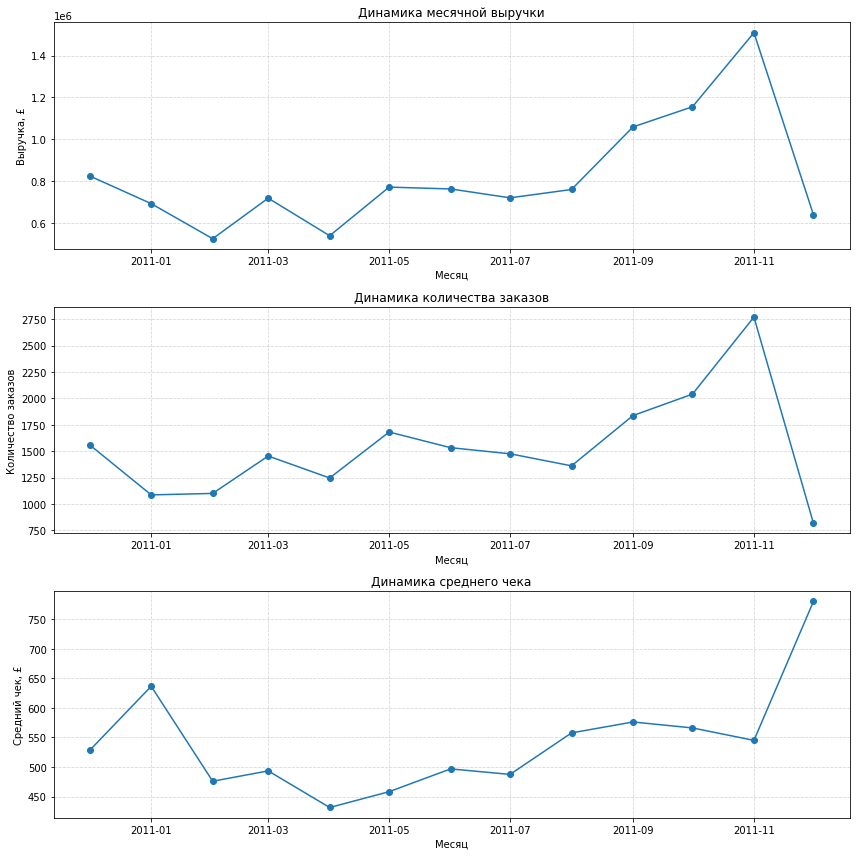

In [67]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

axes[0].plot(monthly_stats["YearMonth"],monthly_stats["monthly_revenue"],marker="o")
axes[0].set_title("Динамика месячной выручки")
axes[0].set_xlabel("Месяц")
axes[0].set_ylabel("Выручка, £")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].plot(monthly_stats["YearMonth"],monthly_stats["monthly_orders"],marker="o")
axes[1].set_title("Динамика количества заказов")
axes[1].set_xlabel("Месяц")
axes[1].set_ylabel("Количество заказов")
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[2].plot(monthly_stats["YearMonth"],monthly_stats["monthly_AOV"],marker="o")
axes[2].set_title("Динамика среднего чека")
axes[2].set_xlabel("Месяц")
axes[2].set_ylabel("Средний чек, £")
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

Основные наблюдения

В течение 2011 года наблюдается заметное увеличение масштаба продаж. Наиболее выраженный рост приходится на осень:

- сентябрь: **+39.45%** к августу;
- октябрь: **+9.11%**;
- ноябрь: **+30.69%**.

В ноябре выручка достигла максимума за наблюдаемый период примерно **£1.51 млн**.

При этом рост осенью в значительной степени связан с увеличением количества заказов, а не только со средним чеком. Например, в ноябре выручка выросла на 30.69%, количество заказов на 35.74% при том что AOV изменился на −3.71%.
Декабрь 2011 нельзя напрямую сравнивать с предыдущими месяцами: данные заканчиваются 9 декабря, поэтому месяц является неполным.

### 5.2 Расчет выручки по заказам
---

Средний чек сам по себе не показывает структуру заказов. Поэтому дополнительно рассчитываю выручку каждого заказа и её распределение.

In [68]:
order_revenue = (clean_data.groupby("InvoiceNo")["Revenue"].sum())
print("Распределение выручки по заказам:")
print(order_revenue.describe(percentiles=[0.75, 0.90, 0.95, 0.99]).round(2))

Распределение выручки по заказам:
count     19960.00
mean        534.40
std        1780.49
min           0.38
50%         303.84
75%         495.62
90%         940.89
95%        1585.92
99%        4821.17
max      168469.60
Name: Revenue, dtype: float64


---

Медианное значение сильно меньше среднего значения при небольшом количестве довольно крупных заказов, формирующих существенный объем выручки, поэтому можно сделать вывод, что распределение асимметрично с правосторонним скосом.

Крупные заказы отражают оптовые сделки. То есть для более глубокого анализа стоит разделять розничные и оптовые сделки. 

### 5.3 География продаж
---

Для каждой страны рассчитываю выручку, количество заказов, количество проданных единиц и средний чек.

In [72]:
country_stats = (clean_data.groupby("Country")
    .agg(country_revenue=("Revenue", "sum"),country_orders=("InvoiceNo", "nunique"),country_quantity=("Quantity", "sum")))
country_stats["revenue_share"] = (country_stats["country_revenue"] / country_stats["country_revenue"].sum() * 100)
country_stats["country_AOV"] = (country_stats["country_revenue"] / country_stats["country_orders"])
uk_revenue_share = country_stats.loc["United Kingdom", "revenue_share"]
print(f"Доля United Kingdom в общей выручке: "f"{uk_revenue_share:.1f}%")
top10_countries = (country_stats.drop("United Kingdom")
    .sort_values("country_revenue", ascending=False).head(10).sort_values("country_revenue"))

Доля United Kingdom в общей выручке: 84.6%


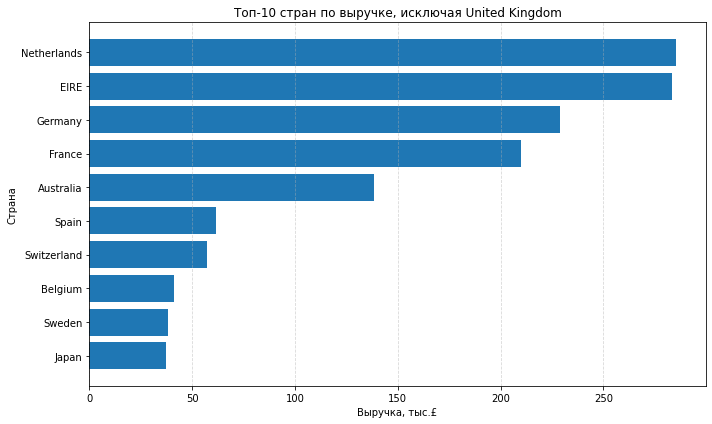

In [73]:
plt.figure(figsize=(10, 6))
plt.barh(top10_countries.index,top10_countries["country_revenue"] / 1000)
plt.xlabel("Выручка, тыс.£")
plt.ylabel("Страна")
plt.title("Топ-10 стран по выручке, исключая United Kingdom")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Продажи имеют выраженную географическую концентрацию, текущая структура продаж сильно зависит от основного рынка – Великобритании, она формирует около **84.6%** всей выручки, значительно опережая остальные страны. Следующие позиции занимают Нидерланды, Ирландия, Германия и Франция, однако их отдельные доли значительно меньше. 

### 5.4 Покупательская активность в течении дня 
---


In [ ]:
hour_stats = (clean_data.groupby("Hour")
    .agg(hour_revenue=("Revenue", "sum"),hour_orders=("InvoiceNo", "nunique"),hour_quantity=("Quantity", "sum")))
hour_stats["hour_AOV"] = (hour_stats["hour_revenue"] /hour_stats["hour_orders"])
hour_stats

,hour_revenue,hour_orders,hour_quantity,hour_AOV
Hour,,,,
6,4.250,1,1,4.250000
7,31059.210,29,15370,1071.007241
8,283868.520,566,159097,501.534488
9,990267.821,1484,518098,667.296375
10,1446742.701,2361,813805,612.766921
11,1239954.440,2396,674682,517.510200
12,1444245.880,3220,839523,448.523565
13,1265736.300,2753,706285,459.766182
14,1181812.371,2457,599220,480.998116


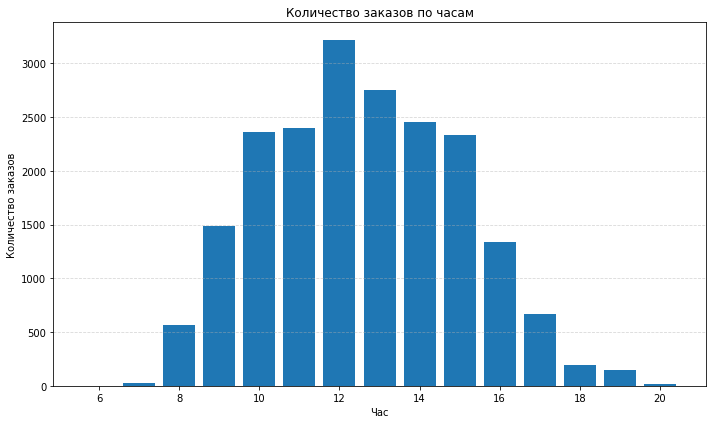

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(hour_stats.index,hour_stats["hour_orders"])
plt.xlabel("Час")
plt.ylabel("Количество заказов")
plt.title("Количество заказов по часам")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

основная нагрузка на продажи приходится на середину рабочего дня — примерно с **10:00** до **15:00**. Максимальное количество заказов наблюдается в **12:00** — **3 220 заказов**.

### 5.5 Товары
---

На этапе очистки было выявлено, что некоторые артикулы товаров относятся к служебным операциям. Поэтому исключаю только заранее выявленные служебные коды.

In [ ]:
service_codes = ["DOT", "M", "m", "POST","AMAZONFEE", "B", "BANK CHARGES","C2", "S"]
product_stats = (clean_data[~clean_data["StockCode"].isin(service_codes)].groupby("StockCode")
    .agg(product_revenue=("Revenue", "sum"),product_orders=("InvoiceNo", "nunique"),product_quantity=("Quantity", "sum")))
description_map = (clean_data.drop_duplicates("StockCode").set_index("StockCode")["Description"])
product_stats["Description"] = (product_stats.index.map(description_map))

In [ ]:
# Исключаем 23843 из рейтингов из-за ранее выявленной
# экстремальной операции с последующей полной отменой.
product_eda = product_stats.drop(index=23843, errors="ignore")

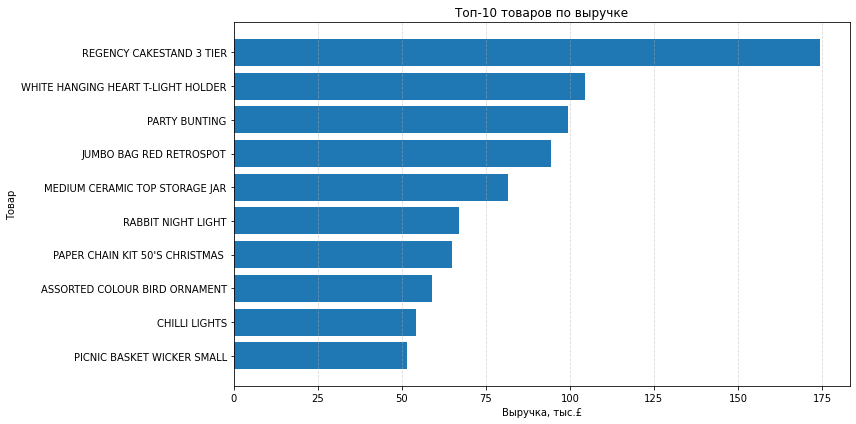

In [74]:
top_revenue_products = (product_eda.sort_values("product_revenue", ascending=False).head(10).sort_values("product_revenue"))
plt.figure(figsize=(12, 6))
plt.barh(top_revenue_products["Description"],top_revenue_products["product_revenue"] / 1000)
plt.xlabel("Выручка, тыс.£")
plt.ylabel("Товар")
plt.title("Топ-10 товаров по выручке")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

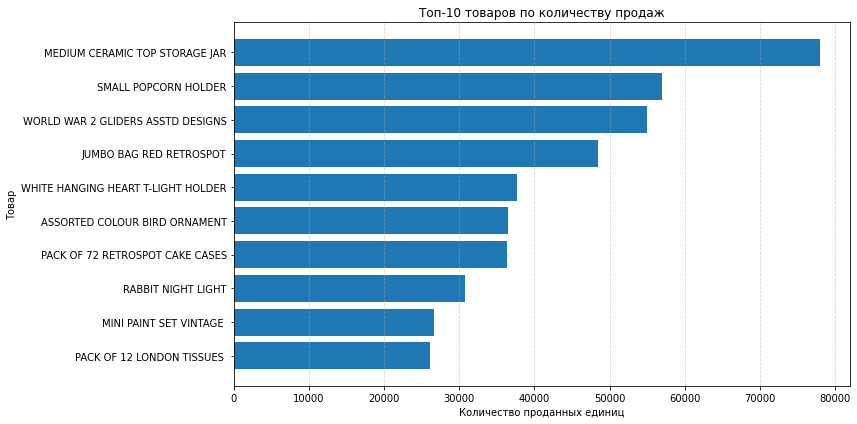

In [ ]:
top_quantity_products = (product_eda.sort_values("product_quantity", ascending=False).head(10).sort_values("product_quantity"))
plt.figure(figsize=(12, 6))
plt.barh(top_quantity_products["Description"],top_quantity_products["product_quantity"])
plt.xlabel("Количество проданных единиц")
plt.ylabel("Товар")
plt.title("Топ-10 товаров по количеству продаж")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Товарный ассортимент характеризуется различиями между лидерами по выручке и по количеству проданных единиц. Поэтому для оценки востребованности товара я рассматриваю оба показателя.

После исключения товара с артикулом 23843 PAPER CRAFT , LITTLE BIRDIE из рейтинга количество проданных единиц перестаёт быть искажено выявленной ранее экстремальной операцией на 80 995 единиц, которая была полностью отменена практически сразу после совершения.

## 6. Анализ клиентов

### 6.1 Основные показатели покупателей

---

In [75]:
customer_data = clean_data[clean_data["CustomerID"].notna()].copy()
print(f"Количество строк: {len(customer_data)}")
print(f"Количество покупателей: {customer_data['CustomerID'].nunique()}")

Количество строк: 397884
Количество покупателей: 4338


В исходных данных около 25% строк не содержат CustomerID, поэтому я не использую их в анализе индивидуального поведения покупателей. 

In [76]:
customer_stats = (customer_data.groupby("CustomerID")
    .agg(customer_revenue=("Revenue", "sum"), customer_orders=("InvoiceNo", "nunique"), customer_quantity=("Quantity", "sum")))
customer_stats["Customer_AOV"] = (customer_stats["customer_revenue"] / customer_stats["customer_orders"])
customer_stats.head()

,customer_revenue,customer_orders,customer_quantity,Customer_AOV
CustomerID,,,,
12346.0,77183.60,1,74215,77183.600000
12347.0,4310.00,7,2458,615.714286
12348.0,1797.24,4,2341,449.310000
12349.0,1757.55,1,631,1757.550000
12350.0,334.40,1,197,334.400000


In [77]:
customer_stats.describe().round(2)

,customer_revenue,customer_orders,customer_quantity,Customer_AOV
count,4338.00,4338.00,4338.00,4338.00
mean,2054.27,4.27,1191.29,419.17
std,8989.23,7.70,5046.08,1796.54
min,3.75,1.00,1.00,3.45
25%,307.41,1.00,160.00,178.62
50%,674.48,2.00,379.00,293.90
75%,1661.74,5.00,992.75,430.11
max,280206.02,209.00,196915.00,84236.25


### 6.2 Концетрация выручки

---


In [78]:
customer_revenue = (customer_stats["customer_revenue"].sort_values(ascending=False))
total_customer_revenue = customer_revenue.sum()
total_customers = len(customer_revenue)
cumulative_revenue = customer_revenue.cumsum()
top_percentages = [0.01, 0.05, 0.10, 0.20]
concentration = pd.DataFrame({"Группа клиентов": ["Топ 1%","Топ 5%","Топ 10%","Топ 20%"],
                              "Количество клиентов": [int(total_customers * p) for p in top_percentages],
                              "Доля выручки": [cumulative_revenue.iloc[int(total_customers * p) - 1] / total_customer_revenue * 100
                                               for p in top_percentages]})
concentration["Доля выручки"] = (concentration["Доля выручки"].round(1))
concentration

,Группа клиентов,Количество клиентов,Доля выручки
0,Топ 1%,43,31.8
1,Топ 5%,216,50.3
2,Топ 10%,433,61.3
3,Топ 20%,867,74.6


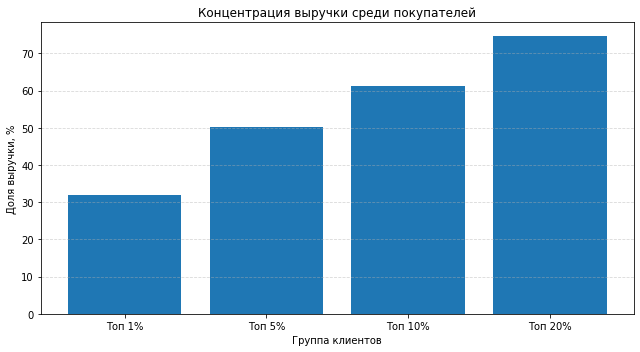

In [79]:
plt.figure(figsize=(9, 5))
plt.bar(concentration["Группа клиентов"],concentration["Доля выручки"])
plt.xlabel("Группа клиентов")
plt.ylabel("Доля выручки, %")
plt.title("Концентрация выручки среди покупателей")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Выручка существенно сконцентрирована среди наиболее ценных клиентов:

**1% клиентов** формируют **31.8%** выручки;
**10% — 61.3%**;
**20% — 74.6%**.

Довольно значительная часть выручки приходится на относительно небольшую группу покупателей. 

### 6.3 Клиенты с одной покупкой и с повторными покупками

---


In [ ]:
customer_stats["customer_type"] = np.where(customer_stats["customer_orders"] == 1,"One-time","Repeat")

In [ ]:
comparison = (customer_stats.groupby("customer_type")
    .agg(clients_count=("customer_revenue", "count"),total_revenue=("customer_revenue", "sum"),avg_revenue=("customer_revenue", "mean"),
        avg_orders=("customer_orders", "mean"),
        avg_AOV=("Customer_AOV", "mean")))
comparison["client_share"] = (comparison["clients_count"] / comparison["clients_count"].sum()* 100)
comparison["revenue_share"] = (comparison["total_revenue"]/ comparison["total_revenue"].sum()* 100)
comparison.round(2)

,clients_count,total_revenue,avg_revenue,avg_orders,avg_AOV,client_share,revenue_share
customer_type,,,,,,,
One-time,1493,616311.73,412.80,1.00,412.80,34.42,6.92
Repeat,2845,8295096.17,2915.68,5.99,422.51,65.58,93.08


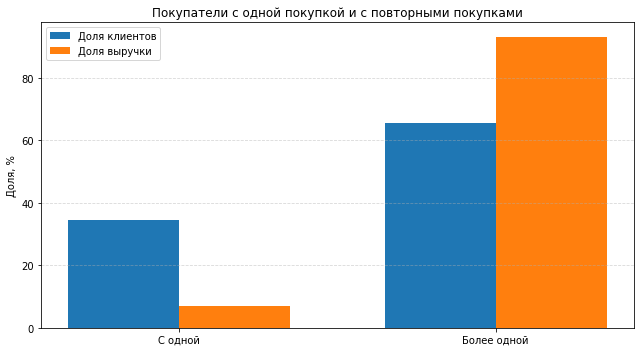

In [ ]:
x = np.arange(len(comparison))
width = 0.35
plt.figure(figsize=(9, 5))
plt.bar(x - width / 2, comparison["client_share"], width, label="Доля клиентов")
plt.bar(x + width / 2, comparison["revenue_share"], width, label="Доля выручки")
plt.xticks(x, ["С одной", "Более одной"])
plt.ylabel("Доля, %")
plt.title("Покупатели с одной покупкой и с повторными покупками")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

--- 
**65.6%** покупателей совершили более одного заказа и сформировали **93.1%** выручки клиентов с известным CustomerID. При этом средние AOV у одноразовых и повторных покупателей близки по значениям. Следовательно, основное различие между группами связано не со значительным отличием среднего чека, а с частотой повторных заказов, то есть следует сосредоточится на удержании покупателей и стимулировании повторных покупок.

### 6.4 Частота 

---

In [ ]:
bins = [1, 2, 6, 11, 21, 51, np.inf]
labels = ["1", "2–5", "6–10", "11–20", "21–50", "51+"]
customer_stats["order_segment"] = pd.cut(customer_stats["customer_orders"],bins=bins,labels=labels,right=False)
order_frequency = (customer_stats["order_segment"].value_counts().sort_index())
order_frequency

order_segment
1        1493
2–5      1973
6–10      535
11–20     242
21–50      80
51+        15
Name: count, dtype: int64

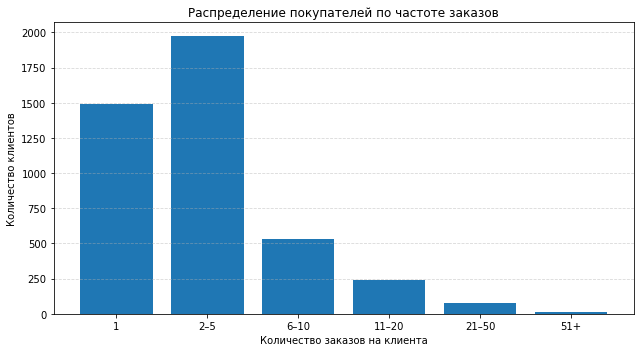

In [ ]:
plt.figure(figsize=(9, 5))
plt.bar(order_frequency.index.astype(str),order_frequency.values)
plt.xlabel("Количество заказов на клиента")
plt.ylabel("Количество клиентов")
plt.title("Распределение покупателей по частоте заказов")
plt.grid(True, axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

Большинство покупателей совершает относительно небольшое количество заказов: около **80% клиентов** имеют от 1 до 5 заказов.
При этом существует небольшая группа клиентов с очень высокой частотой покупок. 

### 6.5 Возвраты покупателей 

---

In [ ]:
returns_data = data[data["InvoiceNo"].str.startswith("C", na=False) & data["CustomerID"].notna()].copy()
print(f"Строк возвратов: {len(returns_data):,}")
print(f"Покупателей с возвратами: {returns_data['CustomerID'].nunique():,}")
print(f"Заказов с возвратами: {returns_data['InvoiceNo'].nunique():,}")

Строк возвратов: 8,905
Покупателей с возвратами: 1,589
Заказов с возвратами: 3,654


In [ ]:
return_stats = (returns_data.groupby("CustomerID").agg(return_orders=("InvoiceNo", "nunique"),
                                                       returned_units=("Quantity", lambda x: x.abs().sum())))
return_stats.describe().round(2)

,return_orders,returned_units
count,1589.00,1589.00
mean,2.30,172.94
std,3.03,2789.79
min,1.00,1.00
25%,1.00,3.00
50%,1.00,8.00
75%,2.00,26.00
max,47.00,80995.00


In [ ]:
customers_with_returns = return_stats.index.nunique()
total_customers = customer_stats.index.nunique()
returning_customers_share = (customers_with_returns / total_customers * 100)
print(f"Доля покупателей с хотя бы одним возвратом: "f"{returning_customers_share:.1f}%")

Доля покупателей с хотя бы одним возвратом: 36.6%


**1,589 из 4,338 покупателей** с известным CustomerID совершали возвраты — около **36.6%** клиентской базы.

При этом распределение количества возвращённых товаров сильно неравномерно: медианный клиент с возвратами вернул **8** единиц, тогда как среднее значение составляет около **173 единиц**. На среднее существенно влияет несколько крупных операций, включая ранее выявленный полностью отменённый экстремальный заказ.

## 7. RFM-анализ

---

### 7.1 Расчет RFM-метрик

In [ ]:
customer_data = clean_data[clean_data["CustomerID"].notna()].copy()
analysis_date = (customer_data["InvoiceDate"].max() + pd.Timedelta(days=1))
rfm = (customer_data.groupby("CustomerID").agg(last_purchase=("InvoiceDate", "max"),
                                               Frequency=("InvoiceNo", "nunique"),Monetary=("Revenue", "sum")))
rfm["Recency"] = (analysis_date - rfm["last_purchase"]).dt.days
rfm = rfm[["Recency", "Frequency", "Monetary"]]
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### 7.2 Расчет RFM-оценок

---

In [ ]:
rfm["R_score"] = pd.qcut(rfm["Recency"],5,labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"),5,labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["Monetary"].rank(method="first"),5,labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_score"] = (rfm["R_score"]+ rfm["F_score"]+ rfm["M_score"])
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,5,7
12347.0,2,7,4310.00,5,5,5,15
12348.0,75,4,1797.24,2,4,4,10
12349.0,19,1,1757.55,4,1,4,9
12350.0,310,1,334.40,1,1,2,4


### 7.3 Сегментация покупателей

---

In [ ]:
def rfm_segment(row):
    r = row["R_score"]
    f = row["F_score"]
    m = row["M_score"]
    if r >= 4 and f >= 4 and m >= 4:
        return "Ключевые"
    elif r >= 3 and f >= 3 and m >= 3:
        return "Лояльные"
    elif r >= 4 and f <= 2:
        return "Новые"
    elif r <= 2 and f >= 4 and m >= 4:
        return "Ценные"
    elif r <= 2 and f >= 3:
        return "Под риском"
    elif r <= 2 and f <= 2:
        return "Ушедшие"
    else:
        return "Потенциальные"

rfm["Segment"] = rfm.apply(rfm_segment,axis=1)

- Ключевые — наиболее активные и ценные клиенты.
- Лояльные — регулярно совершают покупки и имеют устойчивую ценность.
- Ценные — исторически ценные клиенты, но давно не совершали покупок.
- Под риском — ранее активные клиенты с заметным периодом отсутствия покупок.
- Ушедшие — давно не покупали и имеют относительно низкую историческую ценность.
- Потенциальные — относительно недавно начали покупать, но пока имеют невысокую частоту покупок.
- Новые — недавно совершили покупку, но пока имеют небольшую историю взаимодействия.

**Примечание:** Сегменты определены с помощью эвристических правил на основе RFM-оценок. Пороговые значения выбирал для целей данного анализа.

### 7.4 Размер и выручка RFM-сегментов

---


In [ ]:
segment_stats = (rfm.groupby("Segment").agg(customers=("Monetary", "count"),revenue=("Monetary", "sum"),
                                            avg_recency=("Recency", "mean"),avg_frequency=("Frequency", "mean"),
                                            avg_monetary=("Monetary", "mean")))
segment_stats["customer_share"] = (segment_stats["customers"] / len(rfm) * 100)
segment_stats["revenue_share"] = (segment_stats["revenue"] / rfm["Monetary"].sum() * 100)
segment_stats = segment_stats.sort_values("revenue",ascending=False)
segment_stats.round(2)

,customers,revenue,avg_recency,avg_frequency,avg_monetary,customer_share,revenue_share
Segment,,,,,,,
Ключевые,962,5809341.07,12.86,11.08,6038.82,22.18,65.19
Лояльные,758,1396691.42,35.69,4.13,1842.60,17.47,15.67
Ушедшие,1065,519408.57,217.90,1.10,487.71,24.55,5.83
Под риском,477,430691.53,162.19,2.66,902.92,11.00,4.83
Ценные,166,369840.02,125.99,5.54,2227.95,3.83,4.15
Потенциальные,591,239268.72,43.57,1.67,404.85,13.62,2.68
Новые,319,146166.57,18.52,1.24,458.20,7.35,1.64


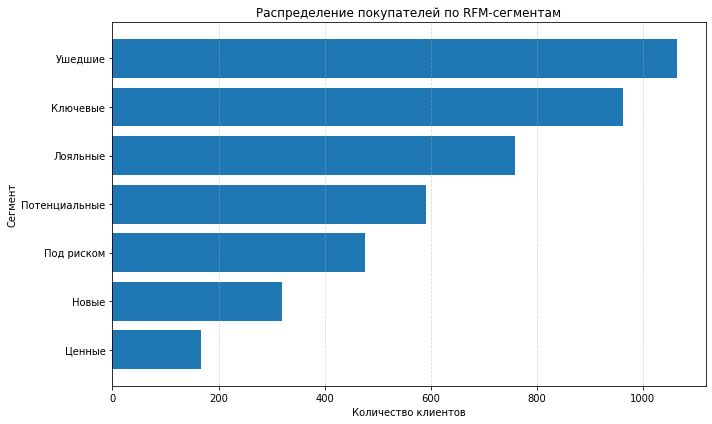

In [ ]:
segment_by_customers = (segment_stats.sort_values("customers"))
plt.figure(figsize=(10, 6))
plt.barh(segment_by_customers.index,segment_by_customers["customers"])
plt.xlabel("Количество клиентов")
plt.ylabel("Сегмент")
plt.title("Распределение покупателей по RFM-сегментам")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

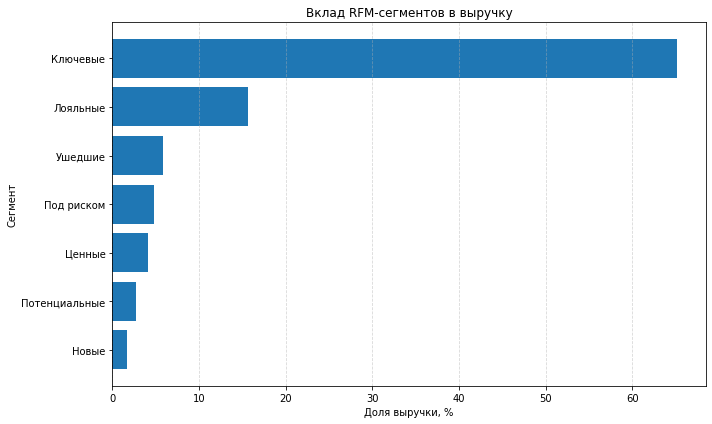

In [ ]:
segment_by_revenue = (segment_stats.sort_values("revenue_share"))
plt.figure(figsize=(10, 6))
plt.barh(segment_by_revenue.index,segment_by_revenue["revenue_share"])
plt.xlabel("Доля выручки, %")
plt.ylabel("Сегмент")
plt.title("Вклад RFM-сегментов в выручку")
plt.grid(True, axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Основные наблюдения

RFM-анализ показывает выраженную неоднородность клиентской базы:
- небольшая группа Ключевых клиентов формирует основную часть выручки;
- значительная часть клиентов давно не совершала покупок;
- существует отдельная группа Ценных клиентов с высокой исторической ценностью, но низкой текущей активностью;
- часть относительно новых покупателей пока имеет небольшую частоту покупок.

## 8. Когортный анализ

---

In [ ]:
cohort_data = customer_data[["CustomerID", "InvoiceDate"]].copy()
cohort_data["PurchaseMonth"] = (cohort_data["InvoiceDate"].dt.to_period("M"))
cohort_data["CohortMonth"] = (cohort_data.groupby("CustomerID")["PurchaseMonth"].transform("min"))
cohort_data["CohortIndex"] = ((cohort_data["PurchaseMonth"].dt.year - cohort_data["CohortMonth"].dt.year) * 12 + (cohort_data["PurchaseMonth"].dt.month - cohort_data["CohortMonth"].dt.month))
cohort_data[["CustomerID", "PurchaseMonth", "CohortMonth", "CohortIndex"]].head(10)

,CustomerID,PurchaseMonth,CohortMonth,CohortIndex
0,17850.0,2010-12,2010-12,0
1,17850.0,2010-12,2010-12,0
2,17850.0,2010-12,2010-12,0
3,17850.0,2010-12,2010-12,0
4,17850.0,2010-12,2010-12,0
5,17850.0,2010-12,2010-12,0
6,17850.0,2010-12,2010-12,0
7,17850.0,2010-12,2010-12,0
8,17850.0,2010-12,2010-12,0
9,13047.0,2010-12,2010-12,0


In [81]:
cohort_counts = (cohort_data.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index())
cohort_matrix = cohort_counts.pivot(index="CohortMonth",columns="CohortIndex",values="CustomerID")
cohort_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,885.0,324.0,286.0,340.0,321.0,352.0,321.0,309.0,313.0,350.0,331.0,445.0,235.0
2011-01,417.0,92.0,111.0,96.0,134.0,120.0,103.0,101.0,125.0,136.0,152.0,49.0,NaN
2011-02,380.0,71.0,71.0,108.0,103.0,94.0,96.0,106.0,94.0,116.0,26.0,NaN,NaN
2011-03,452.0,68.0,114.0,90.0,101.0,76.0,121.0,104.0,126.0,39.0,NaN,NaN,NaN
2011-04,300.0,64.0,61.0,63.0,59.0,68.0,65.0,78.0,22.0,NaN,NaN,NaN,NaN
2011-05,284.0,54.0,49.0,49.0,59.0,66.0,75.0,27.0,NaN,NaN,NaN,NaN,NaN
2011-06,242.0,42.0,38.0,64.0,56.0,81.0,23.0,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,188.0,34.0,39.0,42.0,51.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,169.0,35.0,42.0,41.0,21.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
retention_matrix = (cohort_matrix.divide(cohort_matrix.iloc[:, 0], axis=0)* 100)
retention_matrix = retention_matrix.round(1)
retention_matrix

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,100.0,36.6,32.3,38.4,36.3,39.8,36.3,34.9,35.4,39.5,37.4,50.3,26.6
2011-01,100.0,22.1,26.6,23.0,32.1,28.8,24.7,24.2,30.0,32.6,36.5,11.8,NaN
2011-02,100.0,18.7,18.7,28.4,27.1,24.7,25.3,27.9,24.7,30.5,6.8,NaN,NaN
2011-03,100.0,15.0,25.2,19.9,22.3,16.8,26.8,23.0,27.9,8.6,NaN,NaN,NaN
2011-04,100.0,21.3,20.3,21.0,19.7,22.7,21.7,26.0,7.3,NaN,NaN,NaN,NaN
2011-05,100.0,19.0,17.3,17.3,20.8,23.2,26.4,9.5,NaN,NaN,NaN,NaN,NaN
2011-06,100.0,17.4,15.7,26.4,23.1,33.5,9.5,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.0,18.1,20.7,22.3,27.1,11.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.0,20.7,24.9,24.3,12.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


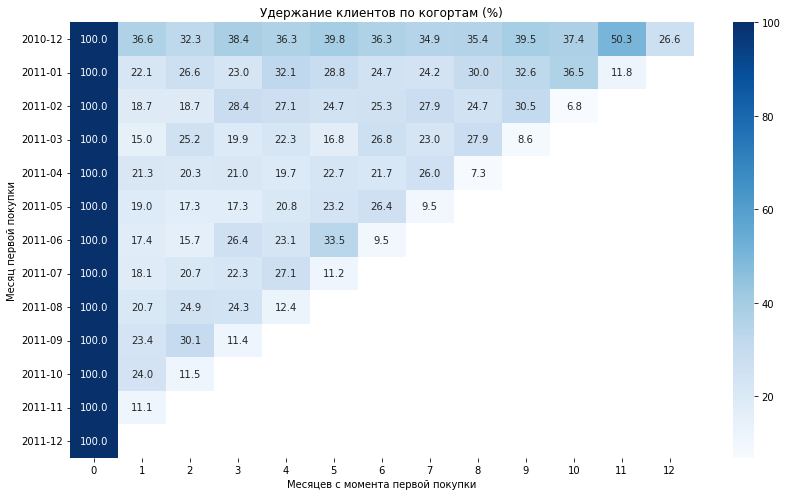

In [83]:
plt.figure(figsize=(12, 7))
sns.heatmap(retention_matrix, annot=True, fmt=".1f", cmap="Blues")
plt.xlabel("Месяцев с момента первой покупки")
plt.ylabel("Месяц первой покупки")
plt.title("Удержание клиентов по когортам (%)")
plt.tight_layout()
plt.show()

По результатам когортного анализа видно, что наибольшее снижение удержания клиентов происходит уже в первые месяцы после первой покупки: в большинстве когорт через месяц возвращается около **15–24%** клиентов. В дальнейшем доля возвращающихся клиентов в основном находится в диапазоне **20–30%**, хотя заметно меняется от месяца к месяцу. При этом у некоторых когорт наблюдается более высокая активность в отдельные периоды, например у клиентов, впервые купивших товары в июне и сентябре 2011 года. Последние когорты пока нельзя полноценно сравнивать с ранними, так как для них доступно меньше месяцев наблюдения. В целом я вижу, что основной потенциал для роста связан с увеличением доли клиентов, которые совершают повторную покупку после первой.


### Общие выводы и рекомендации

---

Основная часть выручки приходится на Великобританию — около 84.6%, при этом осенью наблюдается заметный рост продаж, особенно в сентябре–ноябре 2011 года. Выручка также сильно сконцентрирована среди клиентов: 20% клиентов формируют около 74.6% клиентской выручки. Повторные клиенты составляют 65.6% клиентской базы, но обеспечивают 93.1% выручки среди клиентов с известным идентификатором. Клиентская база неоднородна, значительную часть выручки формируют наиболее активные клиенты, одновременно с этим большая группа покупателей давно не совершала покупок. Когортный анализ показывает, что наиболее заметное снижение активности происходит в первые месяцы после первой покупки, это говорит о важности не только привлечения новых клиентов, но и их дальнейшего удержания и перевода к повторным покупкам.

некоторые рекомендации:
- Уделить особое внимание ключевым и лояльным клиентам, которые формируют значительную часть выручки.
- Отдельно поработать с ценными клиентами, снизившими активность, поскольку их возврат потенциально может иметь больший эффект, чем работа с менее ценными клиентами.
- Разработать механики, стимулирующие повторную покупку после первого заказа, так как именно на этом этапе наблюдается наиболее заметное снижение активности.